# Comparação de Algoritmos

Este notebook lê um conjunto de pastas `result_XXXX` de dentro de `project/results/` e produz:

1. **Tabela por instância** — linhas = instâncias, colunas agrupadas por algoritmo com `RPD (%) ± DP` e `tempo_exec ± DP`  
2. **Gráfico de pontos** — eixo Y = RPD médio (todas as instâncias), eixo X = tempo médio; um ponto por algoritmo  
3. **Fronteira de Pareto** — gráfico `RPD × tempo` com destaque nos pontos não-dominados

> **RPD** = `((melhor_objetivo - objetivo) / melhor_objetivo) * 100`  
> Um RPD mais baixo significa melhor solução (0% = ótimo).

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings('ignore')

# ==============================================================
# CONFIGURAÇÃO  ← edite aqui
# ==============================================================
# Pastas de resultado desejadas.  Deixe [] para carregar TODAS.
# Exemplo: RESULT_DIRS = ['result_0001', 'result_0002']
RESULT_DIRS = []

# Dataset(s) a analisar.  Deixe [] para todos.
# Exemplo: DATASETS = ['a', 'x']
DATASETS = []
# ==============================================================

NOTEBOOK_DIR  = Path(os.getcwd())
PROJECT_ROOT  = NOTEBOOK_DIR.parent
RESULTS_BASE  = PROJECT_ROOT / 'project' / 'results'
BEST_OBJ_CSV  = PROJECT_ROOT / 'best_solutions' / 'best_objectives.csv'
OUTPUT_DIR    = NOTEBOOK_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Diretório de resultados:', RESULTS_BASE)
print('CSV de melhores objetivos:', BEST_OBJ_CSV)

Diretório de resultados: /home/vinicius/Documents/CEFET/TCC/pfc2/project/results
CSV de melhores objetivos: /home/vinicius/Documents/CEFET/TCC/pfc2/best_solutions/best_objectives.csv


In [2]:
# ── Carrega melhores objetivos ────────────────────────────────
df_best = pd.read_csv(BEST_OBJ_CSV)
df_best['instance'] = df_best['instance'].str.replace('.txt', '', regex=False)
print(f'Melhores objetivos carregados: {len(df_best)} instâncias')

# ── Carrega resultados ────────────────────────────────────────
def carregar_resultados(results_base):
    registros = []
    if RESULT_DIRS:
        result_dirs = sorted([Path(results_base) / d for d in RESULT_DIRS])
    else:
        result_dirs = sorted(Path(results_base).glob('result_*'))

    if not result_dirs:
        print('[AVISO] Nenhuma pasta result_XXXX encontrada em:', results_base)
        return pd.DataFrame()

    for result_dir in result_dirs:
        dataset_dirs = sorted([d for d in result_dir.iterdir() if d.is_dir() and d.name != 'temp'])
        for dataset_dir in dataset_dirs:
            dataset = dataset_dir.name
            if DATASETS and dataset not in DATASETS:
                continue
            for csv_file in sorted(dataset_dir.glob('*.csv')):
                try:
                    df_inst = pd.read_csv(csv_file)
                    df_inst['dataset']    = dataset
                    df_inst['instance']   = csv_file.stem
                    df_inst['result_dir'] = result_dir.name
                    registros.append(df_inst)
                except Exception as e:
                    print('[ERRO] Falha ao ler', csv_file, ':', e)

    if not registros:
        print('[AVISO] Nenhum CSV de instância encontrado.')
        return pd.DataFrame()

    return pd.concat(registros, ignore_index=True)

df_raw = carregar_resultados(RESULTS_BASE)
print('Total de linhas carregadas:', len(df_raw))
if not df_raw.empty:
    print('Algoritmos encontrados:', sorted(df_raw['algo_id'].unique()) if 'algo_id' in df_raw.columns else '(coluna algo_id não encontrada)')

Melhores objetivos carregados: 50 instâncias
Total de linhas carregadas: 100
Algoritmos encontrados: ['gvns']


In [3]:
# ── Filtra feasible ───────────────────────────────────────────
if df_raw.empty:
    df_ok = pd.DataFrame()
else:
    df_ok = df_raw[df_raw['status'] == 'feasible'].copy()
    print('Execuções feasible:', len(df_ok), 'de', len(df_raw))
    df_ok['objective'] = pd.to_numeric(df_ok['objective'], errors='coerce')
    df_ok['exec_time'] = pd.to_numeric(df_ok['exec_time'], errors='coerce')

    # Merge com melhores objetivos
    df_ok = df_ok.merge(
        df_best[['dataset', 'instance', 'best_objective']],
        on=['dataset', 'instance'],
        how='left'
    )
    n_sem_best = df_ok['best_objective'].isna().sum()
    if n_sem_best > 0:
        print(f'[AVISO] {n_sem_best} linhas sem melhor objetivo conhecido.')

    # gap percentual = (objetivo / melhor_objetivo) * 100
    # Valor mais alto = melhor
    df_ok['rpd'] = (df_ok['best_objective'] - df_ok['objective']) / df_ok['best_objective'] * 100
    print('rpd calculado com sucesso.')
    print(df_ok[['dataset','instance','algo_id','rpd','exec_time']].head(10))

Execuções feasible: 100 de 100
rpd calculado com sucesso.
  dataset       instance algo_id  rpd  exec_time
0       a  instance_0001    gvns  0.0    600.030
1       a  instance_0001    gvns  0.0    600.025
2       a  instance_0002    gvns  0.0    600.013
3       a  instance_0002    gvns  0.0    600.011
4       a  instance_0003    gvns  0.0    600.045
5       a  instance_0003    gvns  0.0    600.054
6       a  instance_0004    gvns  0.0    600.023
7       a  instance_0004    gvns  0.0    600.033
8       a  instance_0005    gvns  0.0    601.180
9       a  instance_0005    gvns  0.0    601.319


---
## 1. Tabela por instância × algoritmo

Linhas = instâncias (agrupadas por dataset).  
Para cada algoritmo, duas sub-colunas: **RPD (%) ± DP** e **tempo (s) ± DP**.

In [4]:
def fmt(media, dp, casas=4):
    f = '{:.' + str(casas) + 'f}'
    return f.format(media) + ' ± ' + f.format(dp)

if df_ok.empty or 'rpd' not in df_ok.columns:
    print('[INFO] Nenhum dado disponível para gerar a tabela.')
else:
    df_valido = df_ok.dropna(subset=['rpd', 'exec_time'])

    # Agrega por instância × algoritmo
    grp = df_valido.groupby(['dataset', 'instance', 'algo_id'])
    agg = grp.agg(
        rpd_medio   = ('rpd',   'mean'),
        rpd_dp      = ('rpd',   'std'),
        tempo_media = ('exec_time', 'mean'),
        tempo_dp    = ('exec_time', 'std'),
    ).reset_index()

    agg['rpd_dp']   = agg['rpd_dp'].fillna(0.0)
    agg['tempo_dp'] = agg['tempo_dp'].fillna(0.0)

    agg['rpd_fmt']   = agg.apply(lambda r: fmt(r['rpd_medio'],   r['rpd_dp']),   axis=1)
    agg['tempo_fmt'] = agg.apply(lambda r: fmt(r['tempo_media'], r['tempo_dp']), axis=1)

    # Pivot: algoritmos como colunas de nível superior
    pivot = agg.pivot_table(
        index=['dataset', 'instance'],
        columns='algo_id',
        values=['rpd_fmt', 'tempo_fmt'],
        aggfunc='first'
    )

    # Reordena: para cada algoritmo, primeiro gap depois tempo
    algos = sorted(df_valido['algo_id'].unique())
    ordered_cols = []
    for algo in algos:
        if ('rpd_fmt',   algo) in pivot.columns: ordered_cols.append(('rpd_fmt',   algo))
        if ('tempo_fmt', algo) in pivot.columns: ordered_cols.append(('tempo_fmt', algo))
    pivot = pivot[ordered_cols]

    # Renomeia para apresentação
    pivot.columns = pd.MultiIndex.from_tuples(
        [(algo, 'RPD (%) ± DP' if m == 'rpd_fmt' else 'tempo (s) ± DP')
         for m, algo in pivot.columns],
        names=['Algoritmo', 'Métrica']
    )
    pivot = pivot.reset_index()
    pivot.columns.names = [None, None]

    display(pivot)

    # Exporta
    path_csv = OUTPUT_DIR / 'tabela_instancias_algoritmos.csv'
    pivot.to_csv(path_csv, index=False)
    print('Tabela salva em:', path_csv)

dataset       instance             gvns                   
                              RPD (%) ± DP     tempo (s) ± DP
0        a  instance_0001  0.0000 ± 0.0000  600.0275 ± 0.0035
1        a  instance_0002  0.0000 ± 0.0000  600.0120 ± 0.0014
2        a  instance_0003  0.0000 ± 0.0000  600.0495 ± 0.0064
3        a  instance_0004  0.0000 ± 0.0000  600.0280 ± 0.0071
4        a  instance_0005  0.0000 ± 0.0000  601.2495 ± 0.0983
5        a  instance_0006  0.0000 ± 0.0000  601.2895 ± 0.1294
6        a  instance_0007  0.0000 ± 0.0000  601.0355 ± 0.2524
7        a  instance_0008  0.0000 ± 0.0000  600.8605 ± 0.1153
8        a  instance_0009  9.4340 ± 0.0000  600.1620 ± 0.0283
9        a  instance_0010  2.1005 ± 0.8973  601.3750 ± 0.1160
10       a  instance_0011  5.8362 ± 0.0249  601.1165 ± 0.1096
11       a  instance_0012  0.0000 ± 0.0000  600.1135 ± 0.0276
12       a  instance_0013  0.0000 ± 0.0000  601.0295 ± 0.2298
13       a  instance_0014  0.2002 ± 0.0000  602.2855 ± 0.5226
14       a  instance_0015  0.0000 ± 0.0000  600.9450 ± 0.0000
15       a  instance_0016  0.0000 ± 0.0000  600.1535 ± 0.0163
16       a  instance_0017  0.0000 ± 0.0000  600.0605 ± 0.0148
17       a  instance_0018  0.0000 ± 0.0000  600.4130 ± 0.0424
18       a  instance_0019  0.0000 ± 0.0000  600.1450 ± 0.0481
19       a  instance_0020  0.0000 ± 0.0000  600.0180 ± 0.0014
20       b  instance_0001  0.0000 ± 0.0000  601.0275 ± 0.0262
21       b  instance_0002  0.0000 ± 0.0000  600.6295 ± 0.1421
22       b  instance_0003  0.0000 ± 0.0000  600.4710 ± 0.1075
23       b  instance_0004  0.1635 ± 0.0178  600.7435 ± 0.0191
24       b  instance_0005  0.0453 ± 0.0640  600.5410 ± 0.0651
25       b  instance_0006  0.5872 ± 0.0307  600.8005 ± 0.1280
26       b  instance_0007  0.0000 ± 0.0000  600.1785 ± 0.0530
27       b  instance_0008  0.2422 ± 0.1557  601.6815 ± 0.5353
28       b  instance_0009  0.1732 ± 0.0000  601.2130 ± 0.2630
29       b  instance_0010  0.0000 ± 0.0000  601.5080 ± 0.4879
30       b  instance_0011  0.6898 ± 0.0157  611.8675 ± 0.5791
31       b  instance_0012  0.0000 ± 0.0000  604.9895 ± 1.3965
32       b  instance_0013  0.7119 ± 0.0727  608.7665 ± 1.4093
33       b  instance_0014  0.5460 ± 0.4260  606.9620 ± 0.3946
34       b  instance_0015  0.0645 ± 0.0304  602.1140 ± 0.3182
35       x  instance_0001  0.3684 ± 0.4000  600.8360 ± 0.1923
36       x  instance_0002  0.0000 ± 0.0000  600.2920 ± 0.0269
37       x  instance_0003  0.0499 ± 0.0000  600.9355 ± 0.0021
38       x  instance_0004  0.0000 ± 0.0000  600.5905 ± 0.0318
39       x  instance_0005  0.0000 ± 0.0000  600.9320 ± 0.1739
40       x  instance_0006  0.0372 ± 0.0527  600.6400 ± 0.1103
41       x  instance_0007  0.3006 ± 0.0472  600.9960 ± 0.0354
42       x  instance_0008  1.8750 ± 2.6158  603.3340 ± 0.5926
43       x  instance_0009  0.6098 ± 0.1294  609.2760 ± 1.1795
44       x  instance_0010  0.2333 ± 0.0000  611.8285 ± 1.4757
45       x  instance_0011  0.3066 ± 0.0334  603.4345 ± 0.3613
46       x  instance_0012  0.1368 ± 0.0176  607.8050 ± 0.7142
47       x  instance_0013  0.2290 ± 0.0000  607.9190 ± 0.0721
48       x  instance_0014  0.0408 ± 0.0000  607.5050 ± 0.8358
49       x  instance_0015  0.0000 ± 0.0000  600.7080 ± 0.0849

Tabela salva em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/tabela_instancias_algoritmos.csv


---
## 2. Gráfico de pontos — gap médio × tempo médio por algoritmo

Cada ponto representa um algoritmo.  
Eixo X = média do tempo de execução (s).  
Eixo Y = média do gap percentual (%).  
**Melhor** = alto gap e baixo tempo (canto superior esquerdo).

Gráfico salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/scatter_rpd_tempo.png


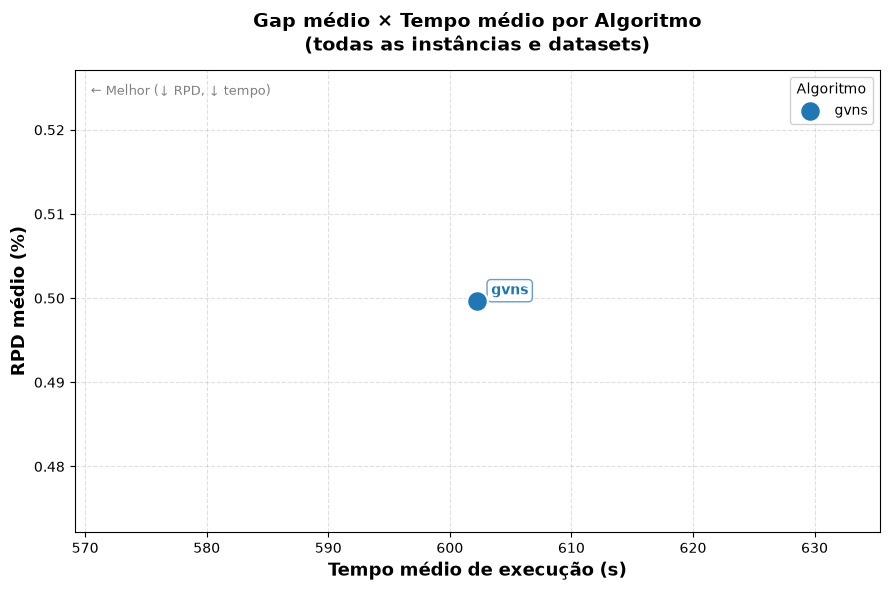

In [5]:
if df_ok.empty or 'rpd' not in df_ok.columns:
    print('[INFO] Nenhum dado disponível para gerar o gráfico.')
else:
    df_valido = df_ok.dropna(subset=['rpd', 'exec_time'])

    # Média geral por algoritmo (todas as instâncias e datasets)
    resumo = df_valido.groupby('algo_id').agg(
        rpd_medio   = ('rpd',   'mean'),
        tempo_medio = ('exec_time', 'mean'),
        n           = ('rpd',   'count'),
    ).reset_index()

    fig, ax = plt.subplots(figsize=(9, 6))

    colors = plt.cm.tab10(np.linspace(0, 1, len(resumo)))

    for i, row in resumo.iterrows():
        ax.scatter(row['tempo_medio'], row['rpd_medio'],
                   s=220, color=colors[i], edgecolors='white', linewidth=1.5,
                   zorder=5, label=row['algo_id'])
        ax.annotate(
            row['algo_id'],
            (row['tempo_medio'], row['rpd_medio']),
            textcoords='offset points', xytext=(10, 5),
            fontsize=10, fontweight='bold', color=colors[i],
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor=colors[i])
        )

    ax.set_xlabel('Tempo médio de execução (s)', fontsize=13, fontweight='bold')
    ax.set_ylabel('RPD médio (%)', fontsize=13, fontweight='bold')
    ax.set_title('Gap médio × Tempo médio por Algoritmo\n(todas as instâncias e datasets)',
                 fontsize=14, fontweight='bold', pad=14)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(title='Algoritmo', fontsize=10, framealpha=0.9)

    # Anotação sobre o canto preferível
    ax.annotate('← Melhor (↓ RPD, ↓ tempo)',
                xy=(0.02, 0.97), xycoords='axes fraction',
                fontsize=9, color='gray', va='top')

    plt.tight_layout()
    path_scatter = OUTPUT_DIR / 'scatter_rpd_tempo.png'
    fig.savefig(path_scatter, dpi=150, bbox_inches='tight')
    print('Gráfico salvo em:', path_scatter)
    plt.show()

---
## 3. Fronteira de Pareto (RPD × tempo)

Critérios: **maximizar gap** e **minimizar tempo**.  
Um algoritmo está na fronteira de Pareto se nenhum outro o supera **em ambos** os critérios simultaneamente.  
Os pontos destacados em vermelho pertencem à fronteira.

In [6]:
def pareto_nao_dominado(df, x_col, y_col, minimize_x=True, maximize_y=False):
    """
    Retorna uma lista booleana indicando quais linhas estão na fronteira de Pareto.
    minimize_x=True  → queremos o menor x possível (tempo)
    maximize_y=True  → queremos o maior y possível (gap)
    """
    n = len(df)
    na_fronteira = [True] * n
    vals = list(zip(df[x_col].tolist(), df[y_col].tolist()))
    for i in range(n):
        xi, yi = vals[i]
        for j in range(n):
            if i == j:
                continue
            xj, yj = vals[j]
            # j domina i se é pelo menos tão bom em AMBOS e estritamente melhor em pelo menos um
            x_j_melhor_ou_igual = (xj <= xi) if minimize_x else (xj >= xi)
            y_j_melhor_ou_igual = (yj >= yi) if maximize_y else (yj <= yi)
            x_j_estritamente    = (xj <  xi) if minimize_x else (xj >  xi)
            y_j_estritamente    = (yj >  yi) if maximize_y else (yj <  yi)
            if x_j_melhor_ou_igual and y_j_melhor_ou_igual and (x_j_estritamente or y_j_estritamente):
                na_fronteira[i] = False
                break
    return na_fronteira

if df_ok.empty or 'rpd' not in df_ok.columns:
    print('[INFO] Nenhum dado disponível para calcular Pareto.')
else:
    df_valido = df_ok.dropna(subset=['rpd', 'exec_time'])

    resumo_algo = df_valido.groupby('algo_id').agg(
        rpd_medio   = ('rpd',   'mean'),
        tempo_medio = ('exec_time', 'mean'),
    ).reset_index()

    pareto_mask = pareto_nao_dominado(
        resumo_algo,
        x_col='tempo_medio', y_col='rpd_medio',
        minimize_x=True, maximize_y=False
    )
    resumo_algo['na_fronteira'] = pareto_mask

    n_front = resumo_algo['na_fronteira'].sum()
    print(f'Algoritmos na fronteira de Pareto: {n_front} de {len(resumo_algo)}')
    display(resumo_algo.sort_values(['na_fronteira', 'rpd_medio'], ascending=[False, True]).reset_index(drop=True))

    # Exporta
    path_pareto_csv = OUTPUT_DIR / 'pareto_algoritmos.csv'
    resumo_algo.to_csv(path_pareto_csv, index=False)
    print('Pareto salvo em:', path_pareto_csv)

Algoritmos na fronteira de Pareto: 1 de 1


,algo_id,rpd_medio,tempo_medio,na_fronteira
0,gvns,0.499635,602.25789,True


Pareto salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/pareto_algoritmos.csv


Gráfico de Pareto salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/pareto_rpd_tempo.png


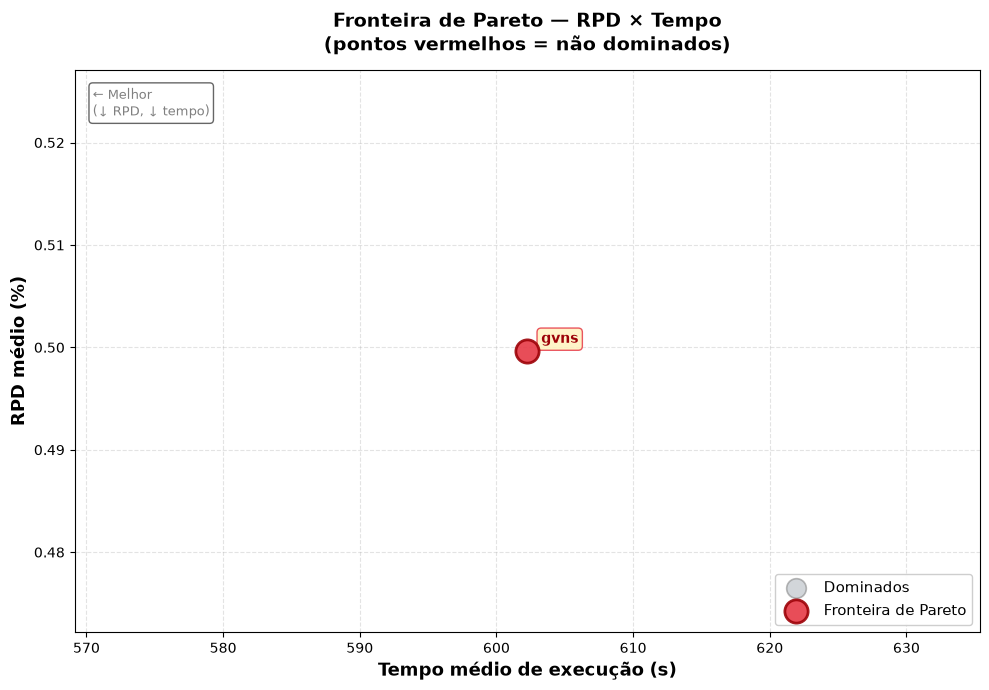

In [7]:
if 'resumo_algo' not in dir() or resumo_algo.empty:
    print('[INFO] Execute a célula de cálculo de Pareto primeiro.')
else:
    fronteira = resumo_algo[resumo_algo['na_fronteira']]
    dominados = resumo_algo[~resumo_algo['na_fronteira']]

    fig, ax = plt.subplots(figsize=(10, 7))

    # Pontos dominados
    ax.scatter(
        dominados['tempo_medio'], dominados['rpd_medio'],
        s=200, alpha=0.55, color='#adb5bd', edgecolors='gray',
        linewidth=1.2, zorder=4, label='Dominados'
    )

    # Pontos na fronteira
    ax.scatter(
        fronteira['tempo_medio'], fronteira['rpd_medio'],
        s=280, alpha=0.9, color='#e63946', edgecolors='#9d0208',
        linewidth=2, zorder=6, label='Fronteira de Pareto'
    )

    # Linha da fronteira (ordenada por tempo)
    if len(fronteira) > 1:
        fs = fronteira.sort_values('tempo_medio')
        ax.step(
            fs['tempo_medio'], fs['rpd_medio'],
            where='post', color='#e63946', alpha=0.45,
            linewidth=2, linestyle='--', zorder=3
        )

    # Rótulos de todos os pontos
    for _, row in resumo_algo.iterrows():
        is_pareto = row['na_fronteira']
        cor    = '#9d0208' if is_pareto else '#6c757d'
        peso   = 'bold'   if is_pareto else 'normal'
        bcolor = '#fff3bf' if is_pareto else 'white'
        ecol   = '#e63946' if is_pareto else 'gray'
        ax.annotate(
            row['algo_id'],
            (row['tempo_medio'], row['rpd_medio']),
            textcoords='offset points', xytext=(10, 6),
            fontsize=10, fontweight=peso, color=cor,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=bcolor, alpha=0.85, edgecolor=ecol)
        )

    ax.set_xlabel('Tempo médio de execução (s)', fontsize=13, fontweight='bold')
    ax.set_ylabel('RPD médio (%)', fontsize=13, fontweight='bold')
    ax.set_title('Fronteira de Pareto — RPD × Tempo\n(pontos vermelhos = não dominados)',
                 fontsize=14, fontweight='bold', pad=14)
    ax.grid(True, linestyle='--', alpha=0.35)

    # Região preferível
    ax.annotate('← Melhor\n(↓ RPD, ↓ tempo)',
                xy=(0.02, 0.97), xycoords='axes fraction',
                fontsize=9, color='gray', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))

    ax.legend(fontsize=11, framealpha=0.95, loc='lower right')

    plt.tight_layout()
    path_pareto_png = OUTPUT_DIR / 'pareto_rpd_tempo.png'
    fig.savefig(path_pareto_png, dpi=150, bbox_inches='tight')
    print('Gráfico de Pareto salvo em:', path_pareto_png)
    plt.show()